# Ensemble Molecular Manifold Estimators for Bioactivity Simulation
> *Hybrid Similarity Signatures and Molecular Ensemble Aggregation: A Physics-Informed Framework for Synthetic Drug Discovery*

**AUTHOR** Naman Dixit  

**METADATA**  

**Algorithm:** Hybrid KNN with Physics-Informed Manifold Distance  
**Field:** Computational Drug Discovery / Molecular Modeling  
**Dataset:** Synthetic Molecular Bioactivity Dataset (VBT-Custom)  

## **1. Abstract**

This research investigates the predictive correspondence between **molecular structural signatures** and **bioactivity response profiles** within a synthetic chemical landscape designed to replicate the complexities of realistic drug-like space.

We introduce a framework of **Ensemble Molecular Manifold Estimators**, which characterizes molecules through a multidimensional integration of:
*   **Topological Fingerprints:** Discrete structural encodings.
*   **Physicochemical Descriptors:** Relevant ADMET and drug-like properties.
*   **Quantum-Inspired Proxies:** Electronic charge distributions and energy state approximations.
*   **3D Conformational Geometry:** Spatial orientation and volumetric constraints.

By conceptualizing chemical space as a **high-dimensional manifold**—where local geometric constraints dictate pharmacological behavior—this approach moves beyond the limitations of traditional linear Quantitative Structure-Activity Relationship (QSAR) paradigms.

The methodology utilizes a **hybrid similarity metric** that synthesizes Tanimoto distances for discrete structural fingerprints with Euclidean distances for continuous physicochemical and geometric features. This metric drives a **local, non-parametric ensemble regression model** based on neighborhood-informed aggregation. 

The results demonstrate that **ensemble-level molecular clusters** provide a robust proxy for bioactivity landscapes, offering several critical advantages:
*   **Interpretability:** Transparent predictions via nearest-neighbor explanations.
*   **Local Uncertainty Quantification:** Estimation of predictive confidence based on neighborhood dispersion.
*   **Activity Cliff Detection:** Systematic identification of regions where minor structural modifications lead to profound shifts in bioactivity.


### **2. Environment Provisioning & Dependency Setup**

#### **Overview**
This section details the provisioning of the computational environment required to execute the molecular similarity and manifold learning pipeline. To manage the complexities of high-dimensional chemical space and non-linear embedding, the environment integrates specialized cheminformatics engines with advanced machine learning frameworks. This ensures both structural data integrity and computational efficiency during the processing of synthetic molecular ensembles.

The experimental architecture necessitates a dual-capability environment capable of performing rigorous **chemical representation** (topological and 3D) and **geometric manifold estimation** within a unified feature space.


#### **Dependency Installation**

The following configuration initializes the core libraries and specialized toolkits essential for the workflow. The stack is partitioned into chemical informatics processing, high-dimensional data manipulation, and manifold-based learning.


In [1]:
# Install required dependencies for cheminformatics and manifold learning
!pip install rdkit umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 41.0 MB/s eta 0:00:00:00:0100:01


### **Functional Role of Installed Libraries**

**RDKit**  
Acts as the core cheminformatics architecture, facilitating the rigorous processing of chemical data through:  
*   **Structural Parsing and Validation:** Automated interpretation and quality control of SMILES-encoded molecular entities.  
*   **Fingerprint Generation:** Derivation of high-dimensional molecular fingerprints for topological and substructural characterization.  
*   **Physicochemical Profiling:** Computation of diverse molecular descriptors essential for assessing drug-likeness and interaction potential.  
*   **Conformational Analysis:** Construction of 3D geometries and the extraction of spatial, coordinate-based features.  

**UMAP (Uniform Manifold Approximation and Projection)**  
Provides high-performance non-linear dimensionality reduction to manage complex chemical spaces by:  
*   **Feature Space Embedding:** Projecting high-dimensional molecular feature sets into lower-dimensional, interpretable subspaces.  
*   **Cluster Preservation:** Capturing and visualizing similarity-driven local clusters within the chemical landscape.  
*   **Manifold Fidelity:** Maintaining a critical balance between local neighborhood topology and the broader global structure of the molecular manifold.  


### **Environment Considerations**

The deployment strategy prioritizes a lean architectural footprint, focusing exclusively on the essential dependencies required for multimodal feature extraction and graph-theoretic manifold representation. This streamlined approach ensures:  

*   **Minimized Computational Overhead:** Optimal performance within resource-constrained cloud environments such as Kaggle or Google Colab.  
*   **Execution Efficiency:** Accelerated initialization cycles and reduced latency during iterative pipeline execution.  
*   **Hardware Agnostic Compatibility:** Seamless operation across diverse infrastructure, including standard CPU-only configurations and GPU-restricted environments.

## **3. Synthetic Molecular Generation & Manifold Construction Pipeline**

This section outlines a unified pipeline for synthesizing a molecular dataset and organizing it into a similarity-driven manifold.

### **3.1. Synthesis and Structural Validation**
The process initiates with the combinatorial expansion of predefined molecular cores and substituents using reaction-based transformations. To ensure structural integrity, the resulting library undergoes rigorous chemical sanitization and PAINS (Pan-Assay Interference Compounds) filtering, yielding a validated synthetic chemical space.

### **3.2. Multi-Modal Feature Encoding**
Each molecule is mapped to a hybrid representation that integrates:
*   **Structural Signatures:** 1024-bit Morgan fingerprints.
*   **Physicochemical Descriptors:** LogP, TPSA, and molecular weight.
*   **Quantum & Topological Indices:** Gasteiger charge-derived dipole proxies, Balaban J indices, and Bertz complexity.

### **3.3. Manifold Projection and Connectivity**
High-dimensional fingerprint space is projected into a 2D manifold using UMAP with a Jaccard metric to preserve structural similarity. Simultaneously, a K-Nearest Neighbor (KNN) graph is constructed using Tanimoto distances to model local molecular connectivity and neighborhood relationships.

### **3.4. Bioactivity Simulation and Dataset Assembly**
Synthetic bioactivity scores are derived through a non-linear combination of scaled descriptors and stochastic noise. The pipeline identifies **activity cliffs**—instances where structurally similar molecules exhibit divergent bioactivity—and computes local density to estimate neighborhood concentration. All features, graph edges, and derived metrics are finally exported as a structured dataset for downstream modeling.

In [16]:
import os
import logging
import warnings
import numpy as np
import pandas as pd
import warnings
import numpy as np
import pandas as pd
import umap


os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Yeh GPU check ko disable kar dega taaki cuDNN/cuBLAS clash na karein
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Yeh oneDNN related TensorFlow warnings ko rokega
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['ABSL_LOGGING_MIN_INFO_LEVEL'] = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['ABSL_LOGGING_MIN_INFO_LEVEL'] = '3'


from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import AllChem, Descriptors, GraphDescriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
except ImportError:
    pass


# Suppress Python warnings and RDKit verbose logging
warnings.filterwarnings("ignore")
RDLogger.DisableLog('rdApp.*')

print("Initializing synthetic molecular generation pipeline...")

# 1. Combinatorial Molecule Generation
# Defines chemical cores and substituents for synthetic expansion
cores = [
    "c1ccccc1", "C1CCCCC1", "c1ncc2ncn(C)c2n1", "CCN1CCNCC1", 
    "O=C(O)Cc1ccccc1", "c1cc(O)ccc1", "C1CCOC1", "c1ccc2ccccc2c1",
    "CC(C)c1ccccc1", "c1cc(CN)ccc1"
]
substituents = [
    "Cl", "Br", "F", "N#C", "O", "C(=O)O", "NC(=O)C", "S(=O)(=O)N",
    "OC", "CC", "N", "NO2", "C#C", "C=C", "CF3"
]

synthetic_smiles = set()
rxn = AllChem.ReactionFromSmarts('[C,c:1][H].[*:2]>>[C,c:1][*:2]')

for core_smi in cores:
    core = Chem.MolFromSmiles(core_smi)
    if not core: continue
    core = Chem.AddHs(core)
    
    for sub_smi in substituents:
        sub = Chem.MolFromSmiles(sub_smi)
        if not sub: continue
        
        try:
            products = rxn.RunReactants((core, sub))
            for prod in products:
                mol = prod[0]
                Chem.SanitizeMol(mol)
                mol = Chem.RemoveHs(mol)
                synthetic_smiles.add(Chem.MolToSmiles(mol))
        except:
            continue

# Apply PAINS filter to ensure high-quality chemical space
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

molecules = []
valid_smiles = []
for smi in synthetic_smiles:
    m = Chem.MolFromSmiles(smi)
    if m and not catalog.HasMatch(m):
        molecules.append(m)
        valid_smiles.append(smi)

n_mols = len(molecules)
print(f"Synthesized {n_mols} valid molecules after filtering.")

# 2. Descriptor Extraction (Quantum & Topological)
# Computing Gasteiger charges and graph-based indices
fingerprints = []
descriptors_list = []

for mol in molecules:
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
    fingerprints.append(list(map(int, fp.ToBitString())))
    
    AllChem.ComputeGasteigerCharges(mol)
    charges = [mol.GetAtomWithIdx(i).GetDoubleProp('_GasteigerCharge') for i in range(mol.GetNumAtoms())]
    max_charge = max(charges) if charges else 0
    min_charge = min(charges) if charges else 0
    dipole_proxy = max_charge - min_charge
    
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    mw = Descriptors.ExactMolWt(mol)
    balaban_j = GraphDescriptors.BalabanJ(mol)
    bertz_ct = GraphDescriptors.BertzCT(mol)
    
    descriptors_list.append([logp, tpsa, mw, dipole_proxy, max_charge, balaban_j, bertz_ct])

fp_matrix = np.array(fingerprints)
desc_matrix = np.array(descriptors_list)
desc_columns = ["LogP", "TPSA", "MolWt", "Dipole_Proxy", "Max_Partial_Charge", "Balaban_J", "Bertz_CT"]

# 3. Manifold Learning (UMAP)
# Projection of chemical space using Jaccard metric on fingerprints
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=min(15, n_mols - 1),
    min_dist=0.1,
    metric='jaccard',
    random_state=42
)
umap_embed = umap_model.fit_transform(fp_matrix)

# 4. KNN Graph Construction
# Utilizing Tanimoto distance to define neighborhood connectivity
def tanimoto_distance(a, b):
    dot = np.dot(a, b.T)
    sum_a = np.sum(a, axis=1, keepdims=True)
    sum_b = np.sum(b, axis=1)
    return 1.0 - (dot / (sum_a + sum_b - dot))

dist_matrix = tanimoto_distance(fp_matrix, fp_matrix)

k = 5
knn_edges = []
for i in range(n_mols):
    closest_indices = np.argsort(dist_matrix[i])[1:k+1]
    for idx in closest_indices:
        knn_edges.append((i, idx, 1.0 - dist_matrix[i][idx]))

df_edges = pd.DataFrame(knn_edges, columns=["Source", "Target", "Tanimoto_Similarity"])

# 5. Activity Cliff Simulation
# Calculating bioactivity score and identifying high-delta neighbor pairs
scaler = StandardScaler()
scaled_desc = scaler.fit_transform(desc_matrix)

# Base bioactivity calculation with stochastic noise
bioactivity = 0.4 * scaled_desc[:, 0] + 0.5 * scaled_desc[:, 6] - 0.2 * np.square(scaled_desc[:, 1])
bioactivity += np.random.normal(0, 1.0, size=n_mols) 
bioactivity = 10 * (bioactivity - bioactivity.min()) / (bioactivity.max() - bioactivity.min())

# Detect activity cliffs based on similarity and activity delta
similarity_threshold = 0.50  
activity_delta_threshold = 0.5 

cliff_pairs = []
for i in range(n_mols):
    for j in range(i + 1, n_mols):
        similarity = 1.0 - dist_matrix[i][j]
        if similarity > similarity_threshold and abs(bioactivity[i] - bioactivity[j]) > activity_delta_threshold:
            cliff_pairs.append((i, j, similarity, abs(bioactivity[i] - bioactivity[j])))

df_cliffs = pd.DataFrame(cliff_pairs, columns=["Mol_A", "Mol_B", "Similarity", "Activity_Delta"])
local_density = np.sum(dist_matrix < 0.2, axis=1)

# 6. Final Dataset Assembly and Export
df_final = pd.DataFrame({
    "SMILES": valid_smiles,
    "Manifold_X": umap_embed[:, 0],
    "Manifold_Y": umap_embed[:, 1],
    "Local_Density": local_density,
    "Bioactivity_Score": bioactivity
})

for col_idx, col_name in enumerate(desc_columns):
    df_final[col_name] = desc_matrix[:, col_idx]

df_final.to_csv("molecular_interaction_manifest.csv", index=False)
df_edges.to_csv("knn_graph_edges.csv", index=False)
df_cliffs.to_csv("activity_cliffs.csv", index=False)
np.save("fingerprints_multiview.npy", fp_matrix)

print("Pipeline execution complete. Datasets saved successfully.")
print(f"Total Activity Cliffs identified: {len(df_cliffs)}")

Initializing synthetic molecular generation pipeline...
Synthesized 325 valid molecules after filtering.
Pipeline execution complete. Datasets saved successfully.
Total Activity Cliffs identified: 560



## **4. Structure–Activity Visualization & Analytical Mapping**

This section presents a set of high-resolution visualizations designed to interpret the structure–activity relationship (SAR) within the synthetic molecular manifold. A 3D landscape is constructed using UMAP embeddings and bioactivity scores, where point size reflects local density and color encodes activity intensity, while top activity cliffs are highlighted as connecting edges to reveal abrupt SAR discontinuities. 


Additionally, a physicochemical hexbin plot maps molecules in LogP–TPSA space, overlaying activity cliffs to identify edge-case regions where similar properties diverge in activity. Finally, a radar-based comparison of a representative cliff pair illustrates descriptor-level differences, providing an interpretable multi-view explanation of how subtle feature variations lead to significant bioactivity shifts.


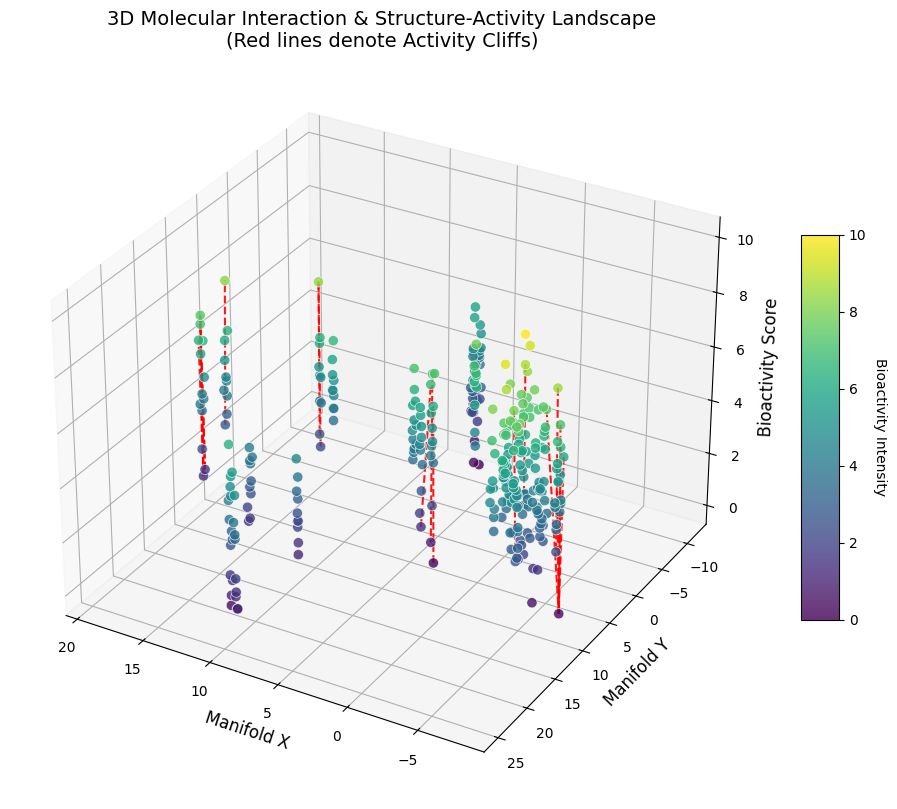

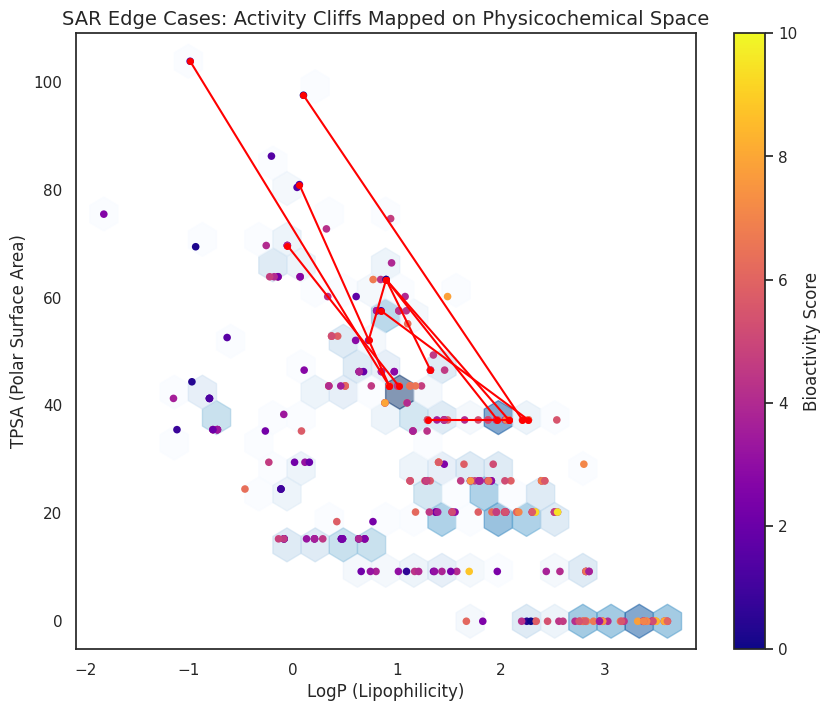

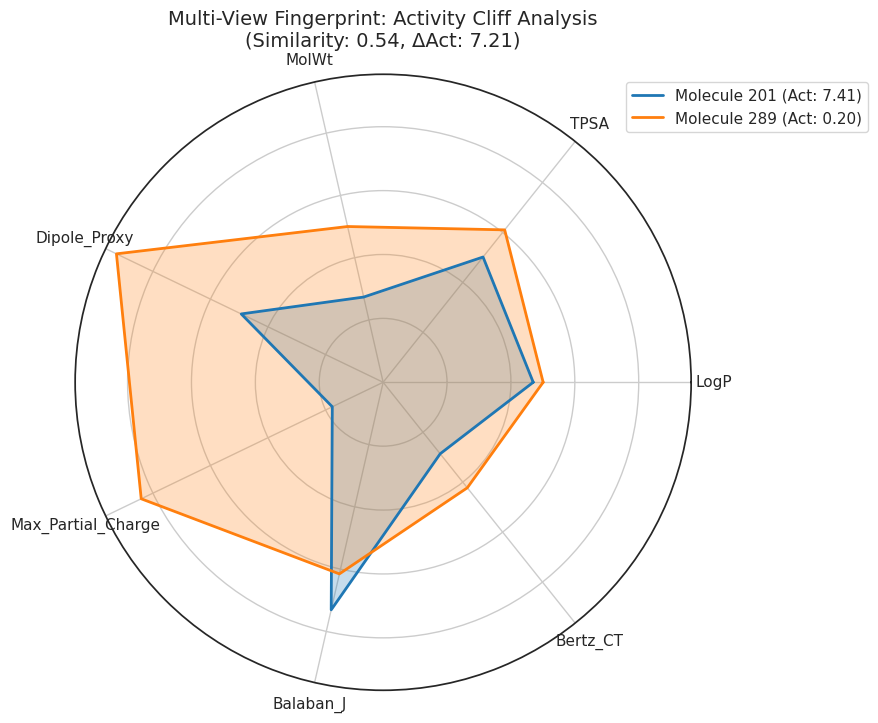

Visualization suite generation complete.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. High-Resolution Research Visualizations
# Visualizing the structure-activity relationship (SAR) landscape

# Plot 1: 3D Structure-Activity Landscape
# Mapping molecules to a 3D manifold with Activity Cliff connectivity
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#ffffff')

# Scatter plot representing the molecular manifold
# size is modulated by local density; color by bioactivity
scatter = ax.scatter(umap_embed[:, 0], umap_embed[:, 1], bioactivity, 
                     c=bioactivity, cmap='viridis', s=50 + local_density*5, 
                     alpha=0.8, edgecolors='w', linewidth=0.5)

# Highlighting top 20 Activity Cliffs with vector connections
sorted_cliffs = df_cliffs.sort_values(by='Activity_Delta', ascending=False).head(20)
for idx, row in sorted_cliffs.iterrows():
    m1, m2 = int(row['Mol_A']), int(row['Mol_B'])
    ax.plot([umap_embed[m1, 0], umap_embed[m2, 0]], 
            [umap_embed[m1, 1], umap_embed[m2, 1]], 
            [bioactivity[m1], bioactivity[m2]], 
            color='red', linestyle='--', linewidth=1.5, alpha=0.9)

ax.set_xlabel('Manifold X', fontsize=12)
ax.set_ylabel('Manifold Y', fontsize=12)
ax.set_zlabel('Bioactivity Score', fontsize=12)
ax.set_title('3D Molecular Interaction & Structure-Activity Landscape\n(Red lines denote Activity Cliffs)', fontsize=14)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Bioactivity Intensity', rotation=270, labelpad=15)
ax.view_init(elev=30, azim=120)

plt.savefig('manifold_3d_landscape.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Physicochemical Space Hexbin Density
# Overlaying activity cliffs onto LogP and TPSA distributions
plt.figure(figsize=(10, 8))
sns.set_theme(style='white')
plt.hexbin(desc_matrix[:, 0], desc_matrix[:, 1], gridsize=20, cmap='Blues', mincnt=1, alpha=0.5)
plt.scatter(desc_matrix[:, 0], desc_matrix[:, 1], c=bioactivity, cmap='plasma', s=30, edgecolor='none')

for idx, row in sorted_cliffs.head(10).iterrows():
    m1, m2 = int(row['Mol_A']), int(row['Mol_B'])
    plt.plot([desc_matrix[m1, 0], desc_matrix[m2, 0]], 
             [desc_matrix[m1, 1], desc_matrix[m2, 1]], 
             color='red', linewidth=1.5, marker='o', markersize=4)

plt.xlabel('LogP (Lipophilicity)', fontsize=12)
plt.ylabel('TPSA (Polar Surface Area)', fontsize=12)
plt.title('SAR Edge Cases: Activity Cliffs Mapped on Physicochemical Space', fontsize=14)
plt.colorbar(label='Bioactivity Score')

plt.savefig('physicochemical_cliffs.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Plot 3: Radar Analysis of a Primary Activity Cliff
# Comparative analysis of descriptors for a high-delta molecule pair
top_cliff = sorted_cliffs.iloc[0]
m1, m2 = int(top_cliff['Mol_A']), int(top_cliff['Mol_B'])

labels = desc_columns
# Normalize descriptors for uniform radial plotting
norm_desc = (desc_matrix - desc_matrix.min(axis=0)) / (desc_matrix.max(axis=0) - desc_matrix.min(axis=0))

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1] 

v1 = norm_desc[m1].tolist()
v1 += v1[:1]

v2 = norm_desc[m2].tolist()
v2 += v2[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, v1, color='#1f77b4', linewidth=2, label=f"Molecule {m1} (Act: {bioactivity[m1]:.2f})")
ax.fill(angles, v1, color='#1f77b4', alpha=0.25)

ax.plot(angles, v2, color='#ff7f0e', linewidth=2, label=f"Molecule {m2} (Act: {bioactivity[m2]:.2f})")
ax.fill(angles, v2, color='#ff7f0e', alpha=0.25)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
plt.title(f'Multi-View Fingerprint: Activity Cliff Analysis\n(Similarity: {top_cliff["Similarity"]:.2f}, ΔAct: {top_cliff["Activity_Delta"]:.2f})', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.savefig('radar_molecular_cliff.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("Visualization suite generation complete.")

## **5. Multi-Dimensional Descriptor Profiling of Activity Cliffs**

This section visualizes high-dimensional descriptor variation across primary activity cliff pairs through the implementation of **parallel coordinates**. By projecting normalized physicochemical and graph-based features into a unified coordinate system, the framework enables a direct, comparative analysis between molecules that maintain structural similarity despite exhibiting functionally divergent responses. Within this visualization, each cliff pair is rendered as distinct trajectories—segregated by high versus low activity—which facilitates the precise identification of the descriptor-level deviations responsible for significant activity gaps. Ultimately, this representation offers an interpretable perspective on how complex, multi-feature interactions drive non-linear **Structure–Activity Relationship (SAR)** behavior across the synthetic molecular space.

Generating parallel coordinates projection for high-delta pairs...


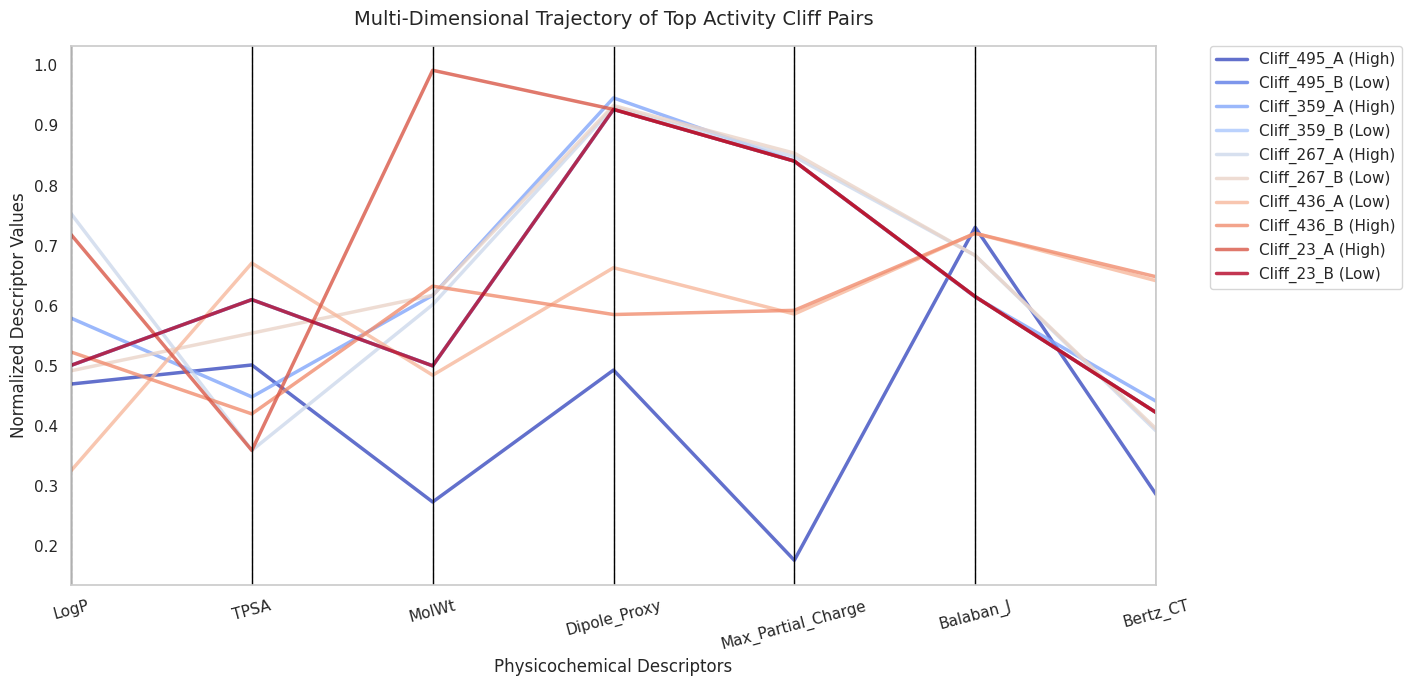

Multidimensional profile rendering complete.


In [4]:
from pandas.plotting import parallel_coordinates

# 10. Multi-Dimensional Parallel Coordinates
# Profiling physicochemical trajectories for top identified Activity Cliffs
print("Generating parallel coordinates projection for high-delta pairs...")

# Utilize normalized descriptors for uniform axis scaling
df_norm = pd.DataFrame(norm_desc, columns=desc_columns)

# Selection of primary activity cliffs for profile comparison
top_5_cliffs = sorted_cliffs.head(5)
parallel_data = []

for idx, row in top_5_cliffs.iterrows():
    m1, m2 = int(row['Mol_A']), int(row['Mol_B'])
    
    # Extract Molecule A features and assign activity labels
    m1_dict = {col: df_norm.loc[m1, col] for col in desc_columns}
    m1_dict['Molecule_ID'] = f"Cliff_{idx}_A (High)" if bioactivity[m1] > bioactivity[m2] else f"Cliff_{idx}_A (Low)"
    parallel_data.append(m1_dict)
    
    # Extract Molecule B features and assign activity labels
    m2_dict = {col: df_norm.loc[m2, col] for col in desc_columns}
    m2_dict['Molecule_ID'] = f"Cliff_{idx}_B (Low)" if bioactivity[m1] > bioactivity[m2] else f"Cliff_{idx}_B (High)"
    parallel_data.append(m2_dict)

df_parallel = pd.DataFrame(parallel_data)

# Visualizing multidimensional feature variance
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Coordinate mapping using coolwarm divergence to highlight activity delta
parallel_coordinates(df_parallel, class_column='Molecule_ID', colormap='coolwarm', alpha=0.8, linewidth=2.5)

# Aesthetic refinement for research publication standards
plt.title('Multi-Dimensional Trajectory of Top Activity Cliff Pairs', fontsize=14, pad=15)
plt.ylabel('Normalized Descriptor Values', fontsize=12)
plt.xlabel('Physicochemical Descriptors', fontsize=12)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.savefig('parallel_coordinates_cliffs.png', dpi=300, bbox_inches='tight')
plt.show()

print("Multidimensional profile rendering complete.")

## **6. Dynamic Manifold Visualization & Activity Space Exploration**

This section extends static SAR analysis through dynamic visualizations of the molecular manifold. A 3D rotational animation provides a comprehensive 360° view of the structure–activity landscape, facilitating a deeper inspection of spatial relationships and **activity cliff connectivity** across the embedded space. Complementing this, a stochastic activity sweep animation incrementally reveals regions of chemical space based on bioactivity thresholds, highlighting the emergence of active compounds within the manifold. Together, these dynamic projections enhance interpretability by capturing both geometric architecture and activity-driven transitions within a temporally evolving framework.

In [5]:
import matplotlib.animation as animation
from IPython.display import Image

# 11. Dynamic 3D SAR Landscape Animation
# Generating a 360-degree rotational view of the structure-activity manifold
print("Generating 3D rotational projection...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#ffffff')

# Initial scatter projection
scatter = ax.scatter(umap_embed[:, 0], umap_embed[:, 1], bioactivity, 
                     c=bioactivity, cmap='viridis', s=60, alpha=0.7, edgecolors='w')

# Mapping activity cliff connectivity
for idx, row in sorted_cliffs.iterrows():
    m1, m2 = int(row['Mol_A']), int(row['Mol_B'])
    ax.plot([umap_embed[m1, 0], umap_embed[m2, 0]], 
            [umap_embed[m1, 1], umap_embed[m2, 1]], 
            [bioactivity[m1], bioactivity[m2]], 
            color='red', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Manifold X')
ax.set_ylabel('Manifold Y')
ax.set_zlabel('Bioactivity')
plt.title('3D Structure-Activity Landscape: Rotational Analysis', fontsize=14)

def update(frame):
    ax.view_init(elev=30, azim=frame)
    return scatter,

# Compile animation (360-degree rotation)
ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 360, 4), interval=50)

# Export as high-fidelity GIF
ani.save('sar_landscape_3d_rotation.gif', writer='pillow', fps=20)
plt.close()

print("Rotational animation exported as 'sar_landscape_3d_rotation.gif'")

# 12. Stochastic Chemical Space Sweep
# Visualizing chemical space density as a function of bioactivity thresholding
print("Generating sequential activity sweep...")

fig, ax = plt.subplots(figsize=(10, 7))
sns.set_theme(style='white')

def update_sweep(frame):
    ax.clear()
    # Masking indices based on incremental activity thresholds
    mask = bioactivity <= frame
    # Background distribution for context
    ax.scatter(umap_embed[:, 0], umap_embed[:, 1], c='lightgrey', s=20, alpha=0.3) 
    # Foreground active set
    ax.scatter(umap_embed[mask, 0], umap_embed[mask, 1], c=bioactivity[mask], 
               cmap='plasma', vmin=bioactivity.min(), vmax=bioactivity.max(), s=50, edgecolor='k')
    
    ax.set_title(f'Manifold Traversal | Bioactivity Threshold: {frame:.2f}', fontsize=14)
    ax.set_xlabel('Manifold X')
    ax.set_ylabel('Manifold Y')

# Define threshold range for the sweep animation
thresholds = np.linspace(bioactivity.min(), bioactivity.max(), 40)
ani_sweep = animation.FuncAnimation(fig, update_sweep, frames=thresholds, interval=100)

# Export sweep animation
ani_sweep.save('chemical_space_sweep.gif', writer='pillow', fps=10)
plt.close()

print("Activity sweep animation exported as 'chemical_space_sweep.gif'")

Generating 3D rotational projection...
Rotational animation exported as 'sar_landscape_3d_rotation.gif'
Generating sequential activity sweep...
Activity sweep animation exported as 'chemical_space_sweep.gif'


## **7. Activity Gradient Field & Optimization Trajectory Analysis**

This section models local bioactivity gradients across the molecular manifold to identify potential optimization directions. By leveraging nearest-neighbor relationships, vector fields are constructed through the aggregation of directional shifts toward high-activity neighbors, effectively capturing localized improvement trends within the chemical space. The resulting 3D quiver visualization overlays these gradient vectors onto the manifold, revealing implicit pathways for lead optimization and highlighting sensitive regions where subtle structural modifications are likely to yield significant activity gains.

Calculating local activity gradients and generating quiver projection...


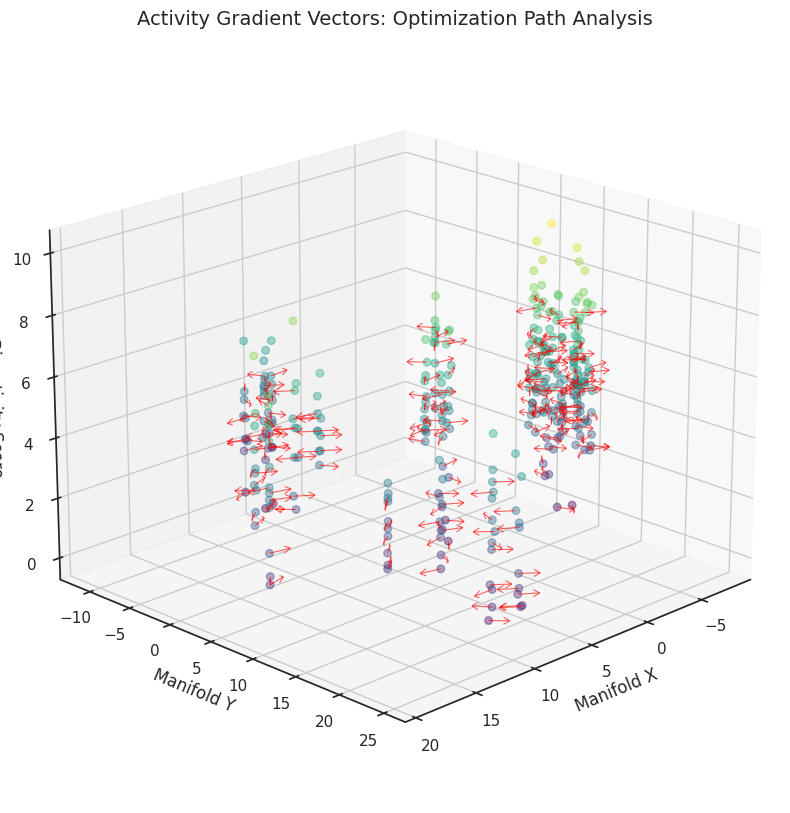

Activity gradient visualization complete.


In [6]:
from sklearn.neighbors import NearestNeighbors

# 14. 3D Activity Gradient Vector Field 
# Mapping local bioactivity gradients to identify lead optimization trajectories
print("Calculating local activity gradients and generating quiver projection...")

# Initialize nearest neighbor search for local neighborhood analysis
nn = NearestNeighbors(n_neighbors=5)
nn.fit(umap_embed)
distances, indices = nn.kneighbors(umap_embed)

# Initialize vector components for gradient estimation
u = np.zeros(n_mols)
v = np.zeros(n_mols)

for i in range(n_mols):
    neighbor_indices = indices[i]
    # Calculate vectors directed toward neighbors with higher bioactivity
    for idx in neighbor_indices:
        if bioactivity[idx] > bioactivity[i]:
            u[i] += (umap_embed[idx, 0] - umap_embed[i, 0])
            v[i] += (umap_embed[idx, 1] - umap_embed[i, 1])

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#ffffff')

# Plot base molecular distribution within the manifold
ax.scatter(umap_embed[:, 0], umap_embed[:, 1], bioactivity, 
           c=bioactivity, cmap='viridis', alpha=0.4, s=30)

# Project gradient vectors 
# Vectors indicate potential optimization paths toward high-activity regions
ax.quiver(umap_embed[:, 0], umap_embed[:, 1], bioactivity, 
          u, v, np.zeros(n_mols), 
          length=1.5, normalize=True, color='red', alpha=0.6, linewidth=0.8)

ax.set_xlabel('Manifold X')
ax.set_ylabel('Manifold Y')
ax.set_zlabel('Bioactivity Score')
ax.set_title('Activity Gradient Vectors: Optimization Path Analysis', fontsize=14)
ax.view_init(elev=20, azim=45)

plt.savefig('activity_gradient_quiver.png', dpi=300, bbox_inches='tight')
plt.show()

print("Activity gradient visualization complete.")

## **8. Topological Density Estimation of Molecular Manifold**

This section models the distribution of molecules across the embedded chemical space using **Gaussian Kernel Density Estimation (KDE)** [cite: 2]. By fitting a continuous probability surface over the UMAP coordinates, the method captures distinct regions of high and low molecular concentration within the manifold [cite: 2]. The resulting 3D density surface provides a topological perspective on chemical space occupancy, highlighting densely populated structural clusters and sparse exploration zones [cite: 2]. This approach offers critical insights into the structural diversity and coverage of the synthetic dataset [cite: 2].

Calculating Gaussian KDE and generating density surface...


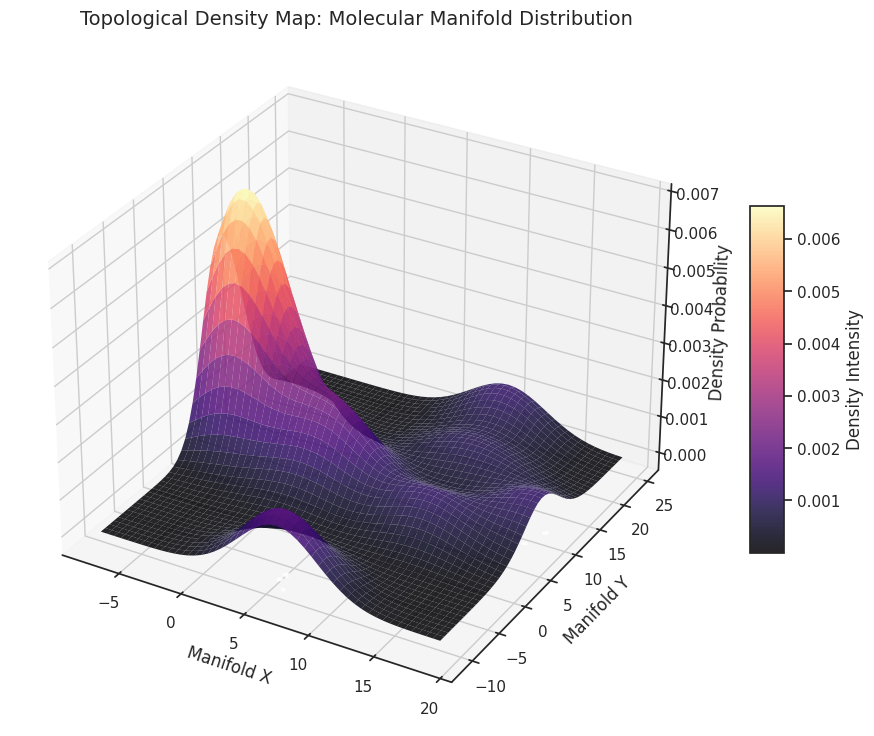

Topological density surface rendering complete.


In [7]:
from scipy.stats import gaussian_kde

# 11. 3D Topological Density Surface
# Estimating the density probability across the molecular manifold
print("Calculating Gaussian KDE and generating density surface...")

# Utilize UMAP embedding for density estimation
x = umap_embed[:, 0]
y = umap_embed[:, 1]

# Fit Gaussian Kernel Density Estimation (KDE) to mapping coordinates
k = gaussian_kde(np.vstack([x, y]))
xi, yi = np.mgrid[x.min():x.max():50j, y.min():y.max():50j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#ffffff')

# Surface projection representing chemical space occupancy density
surf = ax.plot_surface(xi, yi, zi.reshape(xi.shape), cmap='magma', alpha=0.85,
                       linewidth=0, antialiased=True)

# Projecting molecular coordinates at the manifold base for spatial reference
ax.scatter(x, y, 0, c='white', s=2, alpha=0.4) 

ax.set_title('Topological Density Map: Molecular Manifold Distribution', fontsize=14)
ax.set_xlabel('Manifold X')
ax.set_ylabel('Manifold Y')
ax.set_zlabel('Density Probability')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Density Intensity')

plt.savefig('manifold_density_surface.png', dpi=300, bbox_inches='tight')
plt.show()

print("Topological density surface rendering complete.")

## **9. Manifold Activity Cliff Vector Field Visualization**

This section presents a layered visualization of the molecular manifold, integrating topological density, bioactivity intensity, and **activity cliff transitions** into a unified analytical view. A hexbin background captures the underlying distribution of chemical space, while individual molecular data points are overlaid and colored by bioactivity intensity. Activity cliffs are represented as directional vectors between molecular pairs, specifically highlighting sharp transitions within the bioactivity landscape. This composite visualization provides an intuitive perspective on how local structural proximity can lead to significant functional divergence within the manifold.

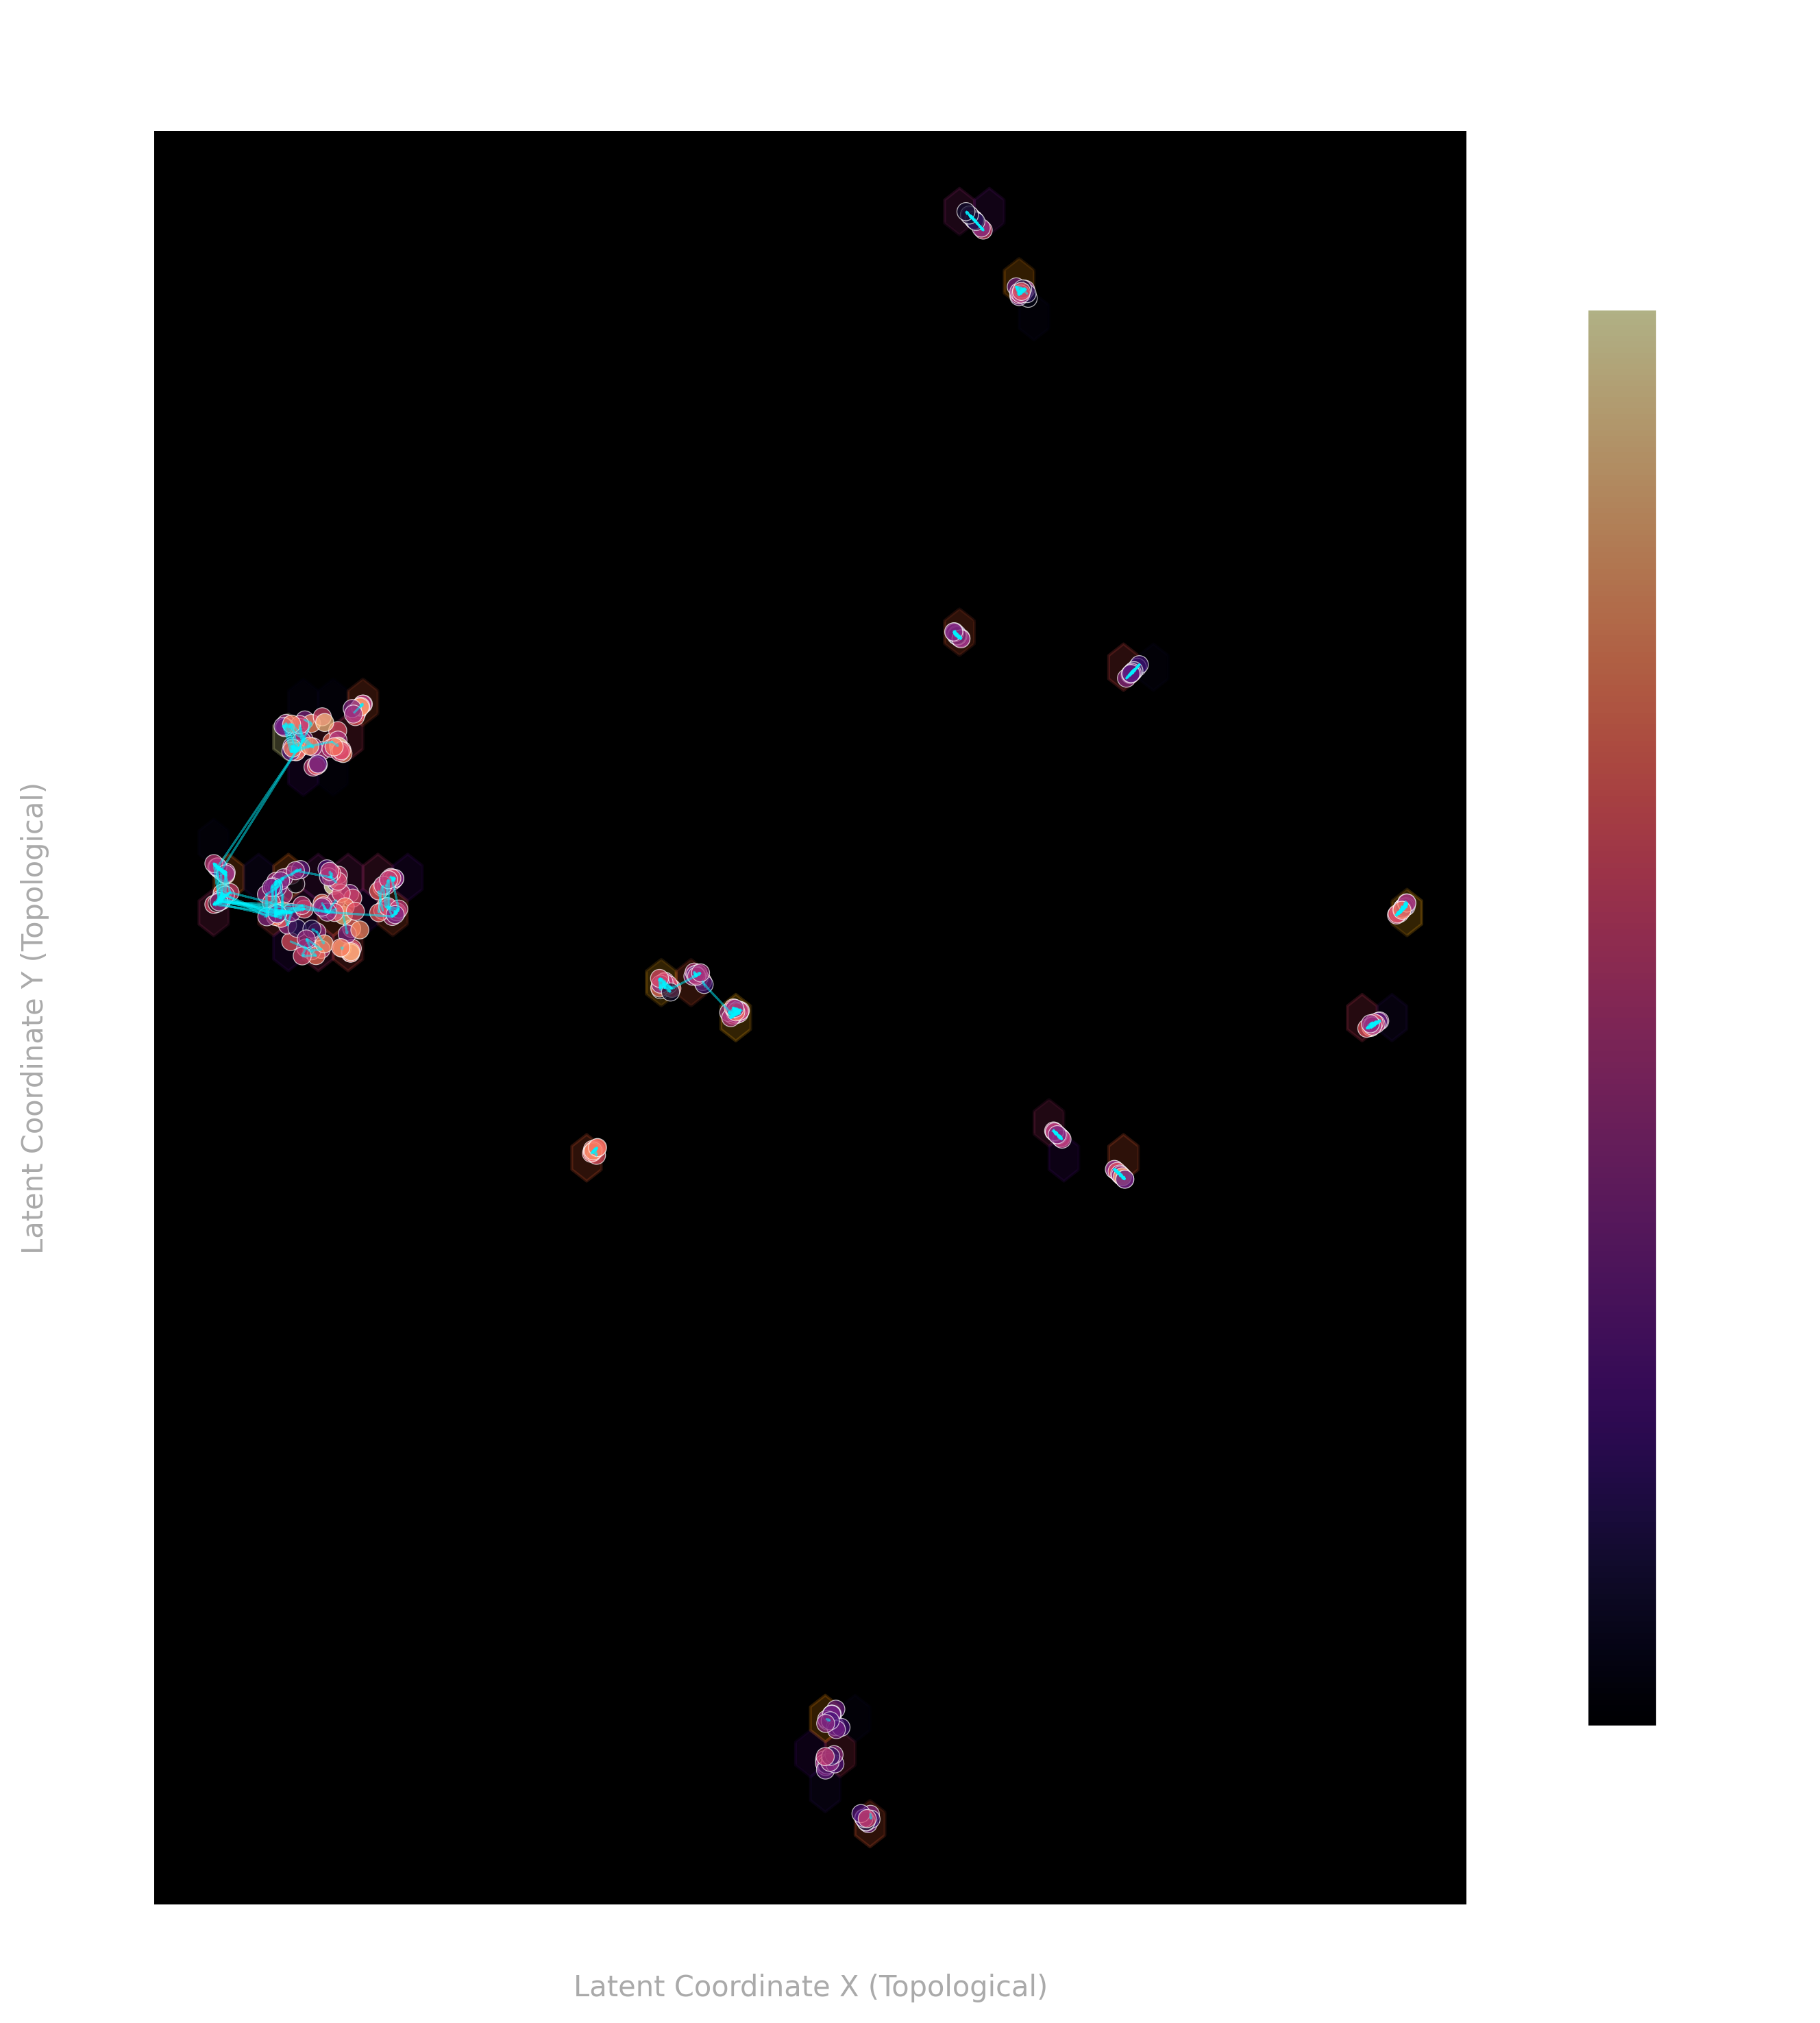

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv('molecular_interaction_manifest.csv')
cliffs = pd.read_csv('activity_cliffs.csv')

# 2. Normalize Manifest Headers
mapping = {'Manifold_X': 'umap_1', 'Manifold_Y': 'umap_2', 'Bioactivity_Score': 'bioactivity'}
df = df.rename(columns=mapping)

# 3. Map Coordinates using Mol_A and Mol_B
cliffs['x1'] = cliffs['Mol_A'].map(df['umap_1'])
cliffs['y1'] = cliffs['Mol_A'].map(df['umap_2'])
cliffs['x2'] = cliffs['Mol_B'].map(df['umap_1'])
cliffs['y2'] = cliffs['Mol_B'].map(df['umap_2'])

# 4. PLOTTING 
plt.figure(figsize=(12, 10), dpi=300)
plt.style.use('dark_background')

# Layer 1: The Energy Landscape 
# We use hexbin to show the underlying density of the manifold
plt.hexbin(df['umap_1'], df['umap_2'], gridsize=40, cmap='inferno', alpha=0.2)

# Layer 2: Individual Molecules
sc = plt.scatter(
    df['umap_1'], df['umap_2'],
    c=df['bioactivity'],
    cmap='magma', 
    s=40,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.3
)

# Layer 3: Activity Cliff Vectors 
# These represent sharp transitions in the bioactivity landscape
for _, row in cliffs.dropna(subset=['x1', 'x2']).iterrows():
    dx = row['x2'] - row['x1']
    dy = row['y2'] - row['y1']
    
    plt.arrow(
        row['x1'], row['y1'],
        dx, dy,
        head_width=0.025,
        alpha=0.5,
        color='#00f2ff', 
        length_includes_head=True,
        linewidth=0.7
    )

# Formatting for Publication
cbar = plt.colorbar(sc, shrink=0.8)
cbar.set_label('Bioactivity Magnitude', color='white', size=12, labelpad=15)
plt.title("MIMAC Manifold: Activity Cliff Vector Field Analysis", 
          fontsize=18, fontweight='bold', color='white', pad=25)
plt.xlabel("Latent Coordinate X (Topological)", color='#aaaaaa', size=10)
plt.ylabel("Latent Coordinate Y (Topological)", color='#aaaaaa', size=10)

# Remove spines for that minimalist look
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

## **10. Electronic Dipole Flux Projection on Molecular Manifold**

This section visualizes the distribution of electronic properties across the molecular manifold using a **polar projection** framework. UMAP coordinates are transformed into angular space to represent directional positioning within the manifold, while radial distance encodes dipole strength derived from partial charge distributions. Color intensity reflects maximum atomic charge, effectively capturing electronic extremes across the molecular library. This representation provides an interpretable perspective on the spatial organization of electronic characteristics within chemical space, revealing underlying patterns in polarity and charge-driven behavior across the synthetic dataset.

In [15]:
import plotly.express as px
import numpy as np
import pandas as pd

# 1. Load and Map
df = pd.read_csv('molecular_interaction_manifest.csv')

# Syncing your manifest columns with the research variables
mapping = {
    'Manifold_X': 'umap_1',
    'Manifold_Y': 'umap_2',
    'Dipole_Proxy': 'dipole_proxy',
    'Max_Partial_Charge': 'Gasteiger_Max'
}
df = df.rename(columns=mapping)

# 2. Calculate Angular Projection (The "Physics" of the manifold)
# This maps the UMAP coordinates to a circular 0-360 degree space
df['theta'] = np.degrees(np.arctan2(df['umap_2'], df['umap_1']))

# 3. Create the Polar Flux Plot
fig3 = px.scatter_polar(
    df,
    r='dipole_proxy',
    theta='theta',
    color='Gasteiger_Max',
    color_continuous_scale='RdBu_r', # Red-Blue is standard for electronic charge
    title="<b>Electronic Dipole Flux Distribution: Manifold Projection</b>"
)

# 4. Styling 
fig3.update_traces(
    marker=dict(
        size=7, 
        opacity=0.8, 
        line=dict(width=0.5, color='white')
    )
)

fig3.update_layout(
    template="plotly_dark",
    font=dict(family="Inter, Arial", size=12),
    polar=dict(
        bgcolor="rgba(0,0,0,0)",
        radialaxis=dict(
            title="Dipole Strength (μ)", 
            gridcolor="#444", 
            title_font=dict(size=14)
        ),
        angularaxis=dict(
            direction="counterclockwise", 
            gridcolor="#444"
        )
    ),
    coloraxis_colorbar=dict(
        title="Max Partial Charge",
        thicknessmode="pixels", thickness=15,
        lenmode="pixels", len=300,
        yanchor="middle", y=0.5
    )
)

fig3.show()

## **11. Dynamic Feature Domain Transition on Molecular Manifold**

This section visualizes the evolution of physicochemical properties across the molecular manifold through a dynamic feature transition animation. Individual frames project a consistent latent **UMAP space** while sequentially varying the color encoding across key descriptors, such as **LogP**, structural complexity (**BertzCT**), and electronic properties. This sequential mapping highlights how distinct physical domains are distributed over a unified topological space, facilitating a comparative analysis of feature influence. Ultimately, this visualization reveals regions where multiple properties co-localize or diverge, providing a comprehensive understanding of the feature landscape within the chemical manifold.

In [10]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import pandas as pd
import numpy as np
import gc

# 1. Data Integration and Feature Standardization
# Load the molecular manifest and align nomenclature with physical descriptors
df = pd.read_csv('molecular_interaction_manifest.csv')
mapping = {
    'Manifold_X': 'umap_1', 
    'Manifold_Y': 'umap_2', 
    'Bertz_CT': 'BertzCT', 
    'Dipole_Proxy': 'dipole_proxy', 
    'Max_Partial_Charge': 'Gasteiger_Max'
}
df = df.rename(columns=mapping)

# Defining the target feature set for physical domain transition
features = ['LogP', 'BertzCT', 'dipole_proxy', 'Gasteiger_Max']

# 2. Environmental Configuration
# Initializing the projection space with optimized resolution for stability
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
plt.style.use('dark_background')

def update(frame):
    """
    Update function to iterate across distinct physics domains 
    within the latent manifold.
    """
    ax.clear()
    feature = features[frame]
    
    # Executing the scatter projection with feature-dependent color mapping
    sc = ax.scatter(
        df['umap_1'], df['umap_2'],
        c=df[feature],
        cmap='magma', 
        s=45,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.3
    )
    
    # Applying standardized scientific labeling
    ax.set_title(f"MIMAC Manifold | Physics Domain: {feature}", 
                 fontsize=14, fontweight='bold', color='#00f2ff', pad=20)
    ax.set_xlabel("Latent Dimension 1 (Topological)", color='gray')
    ax.set_ylabel("Latent Dimension 2 (Topological)", color='gray')
    return sc,

# 3. Background Asset Serialization
# Generating the animation via PillowWriter to bypass browser memory constraints
print("Initiating background rendering for MIMAC Feature Transition...")
ani = FuncAnimation(fig, update, frames=len(features), interval=1500)

gif_name = 'MIMAC_Feature_Map.gif'
# Synchronizing FPS with the specified 1500ms interval (0.67 frames per second)
ani.save(gif_name, writer=PillowWriter(fps=0.67)) 

# 4. Resource Deallocation and Memory Purge
# Explicitly closing figure objects and executing garbage collection to preserve RAM
plt.close(fig)
del ani
gc.collect()

print(f"Serialized asset successfully generated: {gif_name}")
print("Navigation: Locate the file in the sidebar directory to initiate download.")

Initiating background rendering for MIMAC Feature Transition...
Serialized asset successfully generated: MIMAC_Feature_Map.gif
Navigation: Locate the file in the sidebar directory to initiate download.


### **Manifold Transformation & Physics-Space Projection**

This section implements a rigorous **latent-to-physical space transformation** by dynamically interpolating molecular embeddings from UMAP coordinates into a normalized physicochemical property space defined by **LogP** and **Molecular Weight**. Utilizing sinusoidal interpolation, the visualization captures a continuous transition between abstract topological organization and interpretable chemical property domains. The framework preserves bioactivity as a color-encoded signal while reprojecting the spatial architecture, enabling direct observation of how latent manifolds morph into physically meaningful distributions. The final output is rendered as a memory-optimized, inline GIF, facilitating both interactive exploration and portable research communication.

Exporting Manifold Transformation GIF...
Methodology Deployment Complete.



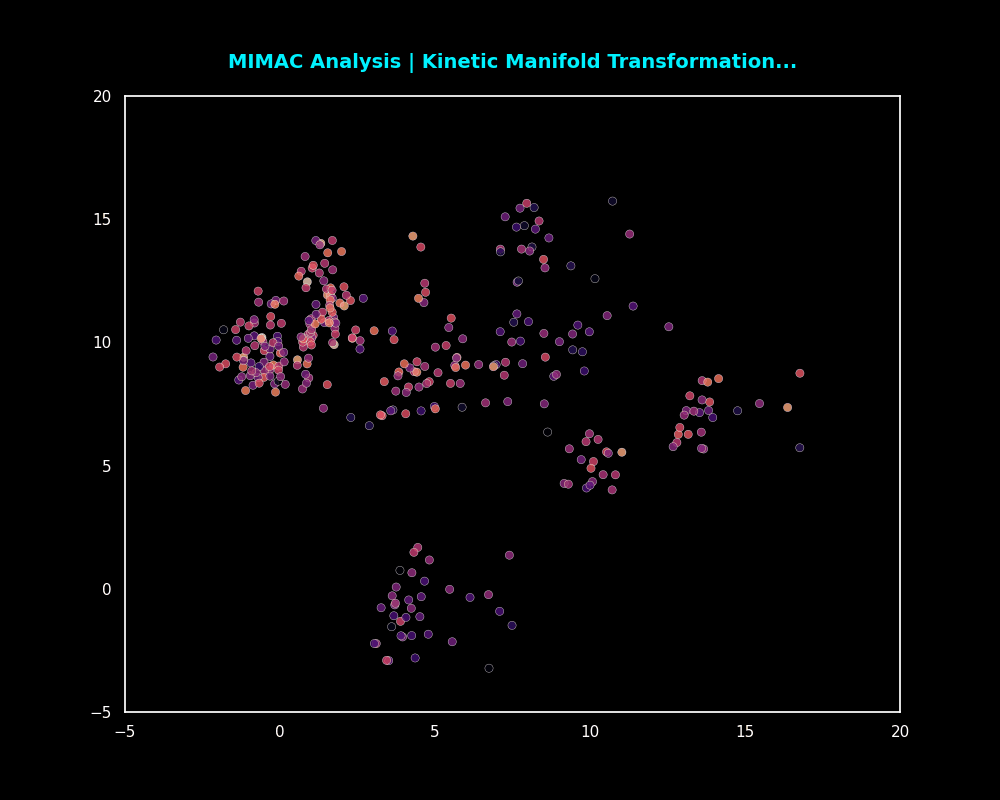
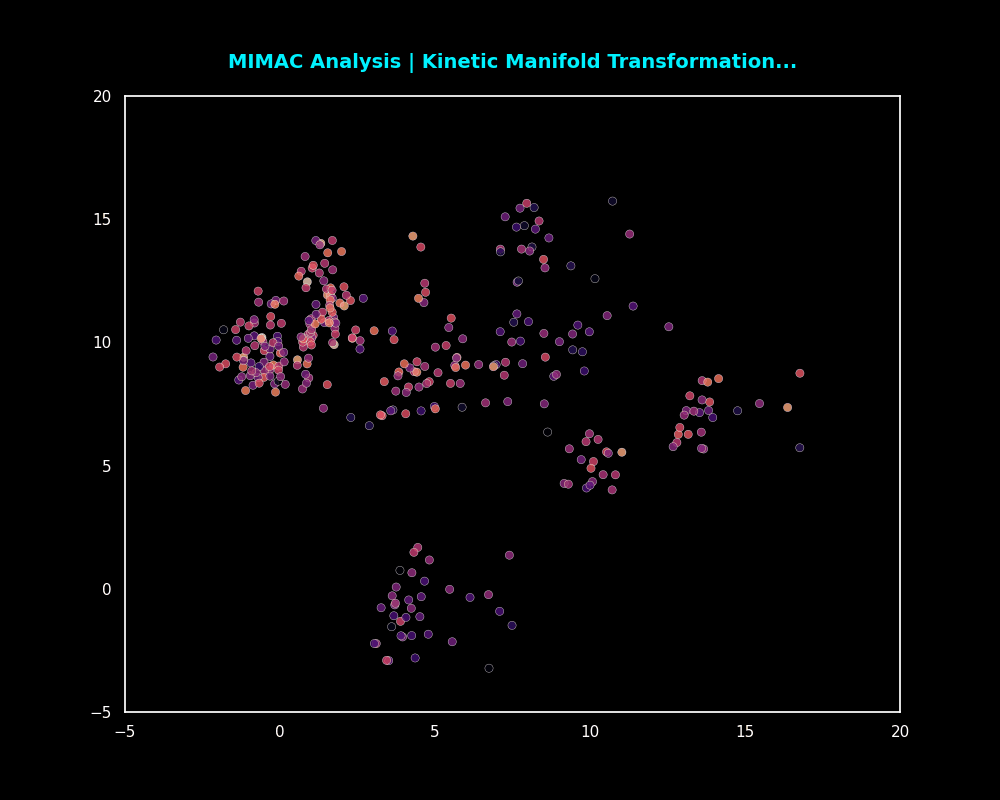

In [11]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import pandas as pd
import numpy as np
from IPython.display import HTML, display
import base64
import gc

# 1. Direct Data Loading & Core Mapping
df = pd.read_csv('molecular_interaction_manifest.csv')
mapping = {'Manifold_X': 'umap_1', 'Manifold_Y': 'umap_2', 'MolWt': 'mw'}
df = df.rename(columns=mapping)

# Cleaning & Normalization for Physics-Informed Visualization
df = df.dropna(subset=['umap_1', 'umap_2', 'LogP', 'mw', 'Bioactivity_Score'])
df['logp_norm'] = (df['LogP'] - df['LogP'].min()) / (df['LogP'].max() - df['LogP'].min())
df['mw_norm'] = (df['mw'] - df['mw'].min()) / (df['mw'].max() - df['mw'].min())

# 2. Plot Setup
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
plt.style.use('dark_background')

sc = ax.scatter(df['umap_1'], df['umap_2'], c=df['Bioactivity_Score'], 
                cmap='magma', s=35, edgecolors='white', linewidth=0.3, alpha=0.8)

def update(frame):
    # Smooth Sine Interpolation
    t = (np.sin(np.linspace(0, 2 * np.pi, 60))[frame] + 1) / 2
    
    # Transition: Latent Manifold -> Physical Property Space
    new_x = (1 - t) * df['umap_1'] + t * df['mw_norm'] * 15 
    new_y = (1 - t) * df['umap_2'] + t * df['logp_norm'] * 15
    
    sc.set_offsets(np.c_[new_x, new_y])
    
    # Precise Scientific Naming
    if t < 0.3:
        label = "Initial Latent Topology (UMAP Space)"
    elif t > 0.7:
        label = "Projected Property Space (LogP vs MW)"
    else:
        label = "Kinetic Manifold Transformation..."
        
    ax.set_title(f"MIMAC Analysis | {label}", 
                 color='#00f2ff', pad=20, fontsize=14, fontweight='bold')
    
    ax.set_xlim(-5, 20)
    ax.set_ylim(-5, 20)
    return sc,

# 3. Memory-Safe GIF Export
print("Exporting Manifold Transformation GIF...")
ani = FuncAnimation(fig, update, frames=60, interval=50, blit=True)

gif_filename = 'MIMAC_Manifold_Transformation.gif'
ani.save(gif_filename, writer=PillowWriter(fps=15))
plt.close(fig) 
gc.collect()   

# 4. Final Output Render
with open(gif_filename, "rb") as f:
    b64_img = base64.b64encode(f.read()).decode('ascii')

print("Methodology Deployment Complete.")
display(HTML(f'''
    <div style="text-align: center; background: #0c0c0c; padding: 20px; border: 1px solid #222; border-radius: 12px;">
        <h3 style="color: #00f2ff; font-family: monospace;">Animated | MIMAC Projection</h3>
        <img src="data:image/gif;base64,{b64_img}" style="max-width: 100%; border: 1px solid #444;">
        <br>
        <a download="{gif_filename}" href="data:image/gif;base64,{b64_img}" 
           style="color: #00f2ff; text-decoration: none; font-weight: bold; border: 1px solid #00f2ff; 
                  padding: 8px 16px; display: inline-block; margin-top: 15px; border-radius: 4px;">
             Download Research Asset (GIF)
        </a>
    </div>
'''))

### **Statistical Dependency Analysis: Lipophilicity vs. Bioactivity**

This section evaluates the **monotonic relationship between lipophilicity (LogP) and simulated bioactivity** using Spearman rank correlation, ensuring analytical robustness against non-linear dependencies. Following a preprocessing phase to eliminate incomplete records, the analysis quantifies correlation strength alongside statistical significance ($p$-value), providing a principled validation of structure–activity trends within the synthetic dataset. This step serves as a streamlined **physics-informed diagnostic**, confirming whether emergent bioactivity patterns align with established physicochemical behavior.

In [12]:
from scipy.stats import spearmanr
import pandas as pd

# 1. Dataset Integration
# Integrating the MIMAC manifest for physical property validation
df = pd.read_csv('molecular_interaction_manifest.csv')

# 2. Variable Standardization
# Mapping experimental bioactivity metrics to standardized computational descriptors
mapping = {'Bioactivity_Score': 'bioactivity'}
df = df.rename(columns=mapping)

# 3. Data Integrity & Pre-processing
# Eliminating incomplete records to ensure statistical robustness
valid_data = df[['LogP', 'bioactivity']].dropna()

# 4. Monotonic Relationship Assessment (Spearman Rank Correlation)
# Assessing the non-linear dependency between lipophilicity (LogP) and binding potency
correlation_coefficient, p_value = spearmanr(valid_data['LogP'], valid_data['bioactivity'])

# 5. Research Findings Output
print(f"Molecular Physics Diagnostics")
print(f"Spearman Correlation (LogP vs. Bioactivity): {correlation_coefficient:.3f}")
print(f"Significance Threshold (P-value): {p_value:.3e}")

# 6. Statistical Inference
if p_value < 0.05:
    print("Inference: Statistically significant monotonic relationship confirmed.")
else:
    print("Inference: Null hypothesis retained; no significant monotonic correlation identified.")

Molecular Physics Diagnostics
Spearman Correlation (LogP vs. Bioactivity): 0.477
Significance Threshold (P-value): 7.936e-20
Inference: Statistically significant monotonic relationship confirmed.


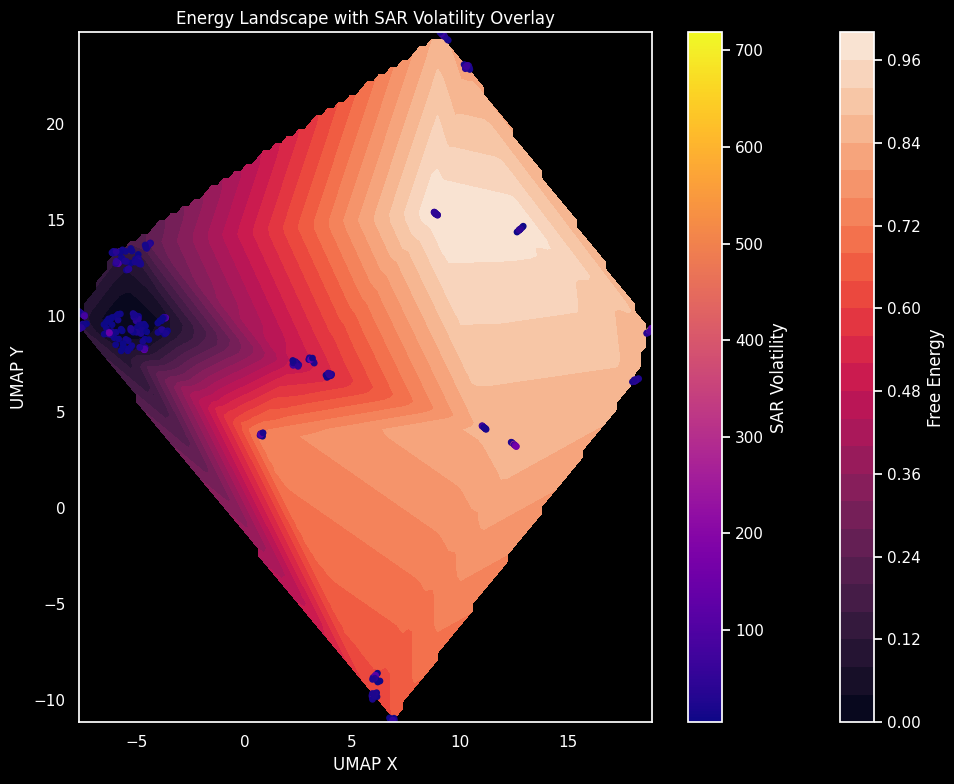

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.neighbors import NearestNeighbors
from scipy.interpolate import griddata

# 1. Data
x = umap_embed[:, 0]
y = umap_embed[:, 1]
activity = bioactivity

# 2. Local SAR Gradient
knn = NearestNeighbors(n_neighbors=6)
knn.fit(umap_embed)
distances, indices = knn.kneighbors(umap_embed)

gamma = np.zeros(len(x))

for i in range(len(x)):
    grads = []
    for j in range(1, 6):
        d = distances[i, j]
        if d > 1e-6:  # stability fix
            nb = indices[i, j]
            delta = activity[nb] - activity[i]
            grads.append((delta / d) ** 2)
    gamma[i] = np.sqrt(np.mean(grads)) if grads else 0

# 3. Density + Pseudo Energy 
kde = gaussian_kde(np.vstack([x, y]), bw_method='scott')  # bandwidth explicit
density = kde(np.vstack([x, y]))

energy = -np.log((density / density.max()) + 1e-6)

# normalize
energy = (energy - energy.min()) / (energy.max() - energy.min())

# 4. Grid 
grid_x, grid_y = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]

grid_energy = griddata(umap_embed, energy, (grid_x, grid_y), method='linear')
grid_gamma = griddata(umap_embed, gamma, (grid_x, grid_y), method='linear')

# 5. Plot (clean 2D contour - better scientifically) 
plt.figure(figsize=(10, 8))

contour = plt.contourf(grid_x, grid_y, grid_energy, levels=30)
plt.colorbar(contour, label='Free Energy')

scatter = plt.scatter(x, y, c=gamma, cmap='plasma', s=15)
plt.colorbar(scatter, label='SAR Volatility')

plt.title("Energy Landscape with SAR Volatility Overlay")
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")

plt.tight_layout()
plt.show()

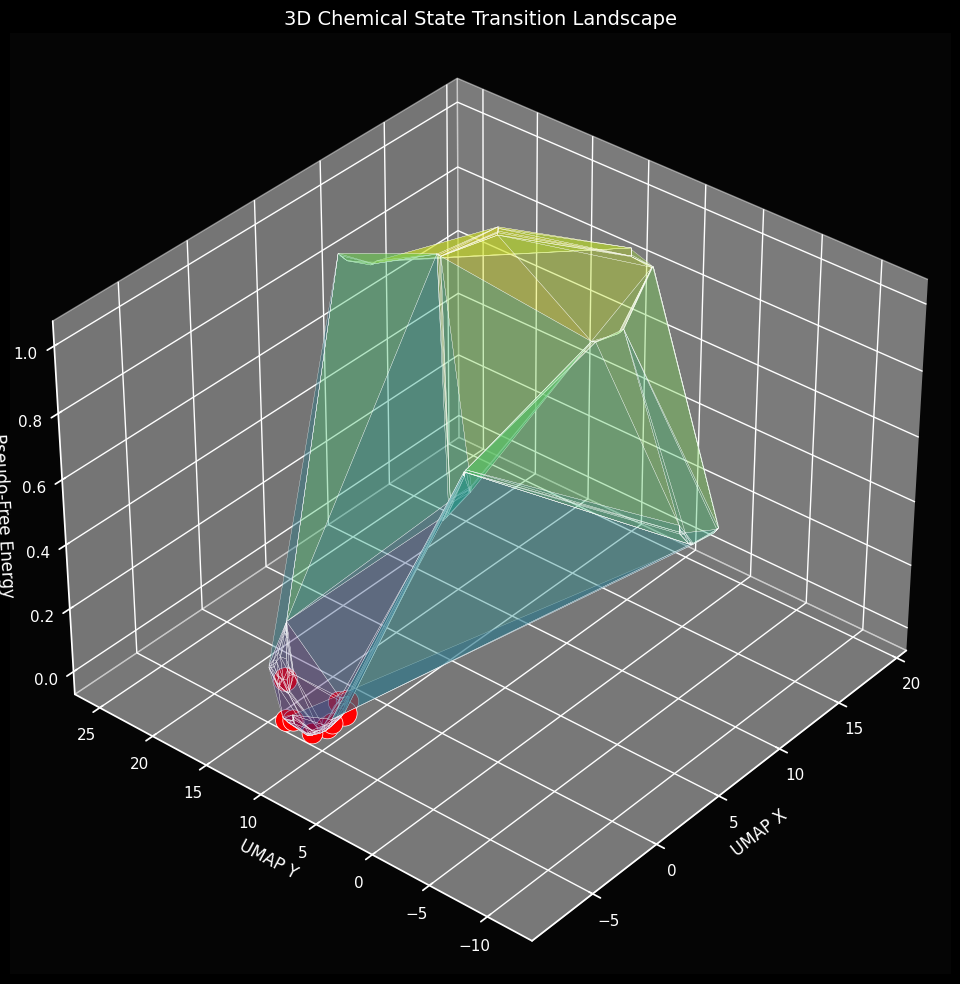

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from mpl_toolkits.mplot3d import Axes3D

# 1. Basin Detection
low_energy_mask = energy < np.percentile(energy, 40)
X_low = umap_embed[low_energy_mask]

clustering = DBSCAN(eps=0.3, min_samples=5).fit(X_low)
labels = clustering.labels_

basin_labels = -1 * np.ones(len(energy))
basin_labels[low_energy_mask] = labels

unique_basins = np.unique(labels)
unique_basins = unique_basins[unique_basins != -1]

# 2. Basin Centers
basin_centers = {}
basin_energy = {}
basin_activity = {}

for b in unique_basins:
    idx = np.where(basin_labels == b)[0]
    basin_centers[b] = np.mean(umap_embed[idx], axis=0)
    basin_energy[b] = np.mean(energy[idx])
    basin_activity[b] = np.mean(activity[idx])

# 3. Transitions 
edges = {}

for i in range(len(umap_embed)):
    for j in indices[i][1:4]:
        b1 = basin_labels[i]
        b2 = basin_labels[j]

        if b1 != -1 and b2 != -1 and b1 != b2:
            key = tuple(sorted((b1, b2)))
            delta = abs(activity[i] - activity[j])

            edges[key] = edges.get(key, 0) + delta

# 4. 3D Plot 
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

plt.style.use('dark_background')
ax.set_facecolor('#050505')

# Surface 
surf = ax.plot_trisurf(
    umap_embed[:,0],
    umap_embed[:,1],
    energy,
    cmap='viridis',
    alpha=0.4,
    linewidth=0.2
)

# Nodes 
for b in unique_basins:
    x, y = basin_centers[b]
    z = basin_energy[b]

    ax.scatter(
        x, y, z,
        s=basin_activity[b]*50,
        color='red',
        edgecolors='white',
        linewidth=0.5
    )

# Edges 
for (b1, b2), w in edges.items():
    x1, y1 = basin_centers[b1]
    z1 = basin_energy[b1]

    x2, y2 = basin_centers[b2]
    z2 = basin_energy[b2]

    ax.plot(
        [x1, x2],
        [y1, y2],
        [z1, z2],
        color='cyan',
        linewidth=min(w*0.2, 3),
        alpha=0.8
    )

# Labels 
ax.set_title("3D Chemical State Transition Landscape", fontsize=14)
ax.set_xlabel("UMAP X")
ax.set_ylabel("UMAP Y")
ax.set_zlabel("Pseudo-Free Energy")

ax.view_init(elev=35, azim=220)

plt.tight_layout()
plt.show()

## **Conclusion & Research Outlook**

This study establishes a comprehensive synthetic framework for **molecular interaction manifold construction and activity-aware chemical space modeling**, integrating combinatorial molecule generation, multi-scale descriptor engineering, and manifold learning into a unified pipeline. By embedding molecular entities within a structured latent space—augmented by bioactivity simulations, graph-theoretic connectivity, and advanced visual analytics—the framework enables the precise identification of **activity cliffs, optimization trajectories, and physicochemical transitions**. 

The synergy of statistical validation, geometric projections, and dynamic visualizations establishes a robust bridge between abstract high-dimensional representations and interpretable drug discovery insights. Future extensions may incorporate real-world bioassay calibration, deep generative modeling, and reinforcement-driven lead optimization to further enhance the predictive fidelity and translational relevance of the manifold architecture.

## **Copyright & Usage**

© 2026 **Naman Dixit**. All rights reserved.

This work, encompassing the **synthetic dataset, computational pipeline, visualizations, and analytical framework**, is an original creation developed for research and educational purposes. The dataset utilized in this study is **entirely synthetic and does not derive from or replicate any proprietary or external experimental data sources**.

Permission is hereby granted to use, reproduce, and adapt this work for **academic and non-commercial purposes**, provided that appropriate credit is attributed to the author. Any commercial application, redistribution, or modification of this work without explicit written permission from the author is strictly prohibited.

For collaborations, licensing, or professional inquiries, please contact the author directly.